Garment Inc is a corporation that handles clothing exports to customers all over Europe. They cater to wholesale business where customers are buying their products either in bulk or retail. 
In order to increase customer retention, the business needs to determine their distinct customer groups to see their purchase behavior so they could take actions for each group. 

After data is preprocessed, check for recent transactions,
frequency and the amount spent by the customers. In order to
create recency variable, decide the reference date - that is one
day prior to the last transaction. RFM analysis is a very popular
customer segmentation and identifiable technique in database
marketing (Christy et al., 2018). It is significant especially in
Retail Industry. Each customer under RFM is scored based on
three factors.
1.  Recency: It refers to the number of days before the reference
date when a customer made the last purchase. Lesser the value
of recency, higher is the customer visit to a store.
2. Frequency: It is the period between two subsequent purchases
of a customer. Higher the value of Frequency, more is the customer visit to the company.
3. Monetary: This refers to the amount of money spent by a customer during a specific period of time. Higher the value, more
is the profit generated to the company

# Imports

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta
import seaborn as sns 

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import joblib

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt






# EDA

In [80]:
df = pd.read_excel("Transactions_LRFM.xlsx")
df




,TRANSACTION_ID,TRANSACTION_DATE,TOTAL_PRICE,CUSTOMER_ID,LOGISTIC_ID,SHIPMENT_CITY,SHIPMENT_COUNTRY,PRODUCT_ID,QUANTITY,PRODUCT_PRICE,PRODUCT_COST,Business Transaction,Product_Category,customer_since_year
0,1025189,2023-01-21,11720,25,4,Dublin,Ireland,38,320,2240,1280,Retail,Sweatshirt,2015
1,1025189,2023-01-21,11720,25,4,Dublin,Ireland,105,290,6380,4350,Retail,Polo Shirt,2015
2,1025189,2023-01-21,11720,25,4,Dublin,Ireland,77,310,3100,2015,Retail,T-Shirt,2015
3,1025190,2023-08-17,36380,24,4,Ludwigshafen am Rhein,Germany,56,670,20100,11725,Bulk,Cardigan,2015
4,1025190,2023-08-17,36380,24,4,Ludwigshafen am Rhein,Germany,105,740,16280,11100,Bulk,Polo Shirt,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110182,1060186,2023-12-28,48940,8,14,Wigan,UK,80,1210,12100,7865,Retail,T-Shirt,2006
110183,1060187,2023-03-15,16380,13,15,Almere Stad,Netherlands,59,90,2700,1575,Bulk,Cardigan,2009
110184,1060187,2023-03-15,16380,13,15,Almere Stad,Netherlands,27,760,13680,7600,Bulk,Hoodie,2009
110185,1060188,2023-04-28,11440,3,12,Hamburg,Germany,77,120,1200,780,Others,T-Shirt,2002


In [81]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 14.29it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Cleaning

Convert the date column to datetime

In [82]:
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])


Drop duplicates

In [83]:
df.drop_duplicates()

,TRANSACTION_ID,TRANSACTION_DATE,TOTAL_PRICE,CUSTOMER_ID,LOGISTIC_ID,SHIPMENT_CITY,SHIPMENT_COUNTRY,PRODUCT_ID,QUANTITY,PRODUCT_PRICE,PRODUCT_COST,Business Transaction,Product_Category,customer_since_year
0,1025189,2023-01-21,11720,25,4,Dublin,Ireland,38,320,2240,1280,Retail,Sweatshirt,2015
1,1025189,2023-01-21,11720,25,4,Dublin,Ireland,105,290,6380,4350,Retail,Polo Shirt,2015
2,1025189,2023-01-21,11720,25,4,Dublin,Ireland,77,310,3100,2015,Retail,T-Shirt,2015
3,1025190,2023-08-17,36380,24,4,Ludwigshafen am Rhein,Germany,56,670,20100,11725,Bulk,Cardigan,2015
4,1025190,2023-08-17,36380,24,4,Ludwigshafen am Rhein,Germany,105,740,16280,11100,Bulk,Polo Shirt,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110182,1060186,2023-12-28,48940,8,14,Wigan,UK,80,1210,12100,7865,Retail,T-Shirt,2006
110183,1060187,2023-03-15,16380,13,15,Almere Stad,Netherlands,59,90,2700,1575,Bulk,Cardigan,2009
110184,1060187,2023-03-15,16380,13,15,Almere Stad,Netherlands,27,760,13680,7600,Bulk,Hoodie,2009
110185,1060188,2023-04-28,11440,3,12,Hamburg,Germany,77,120,1200,780,Others,T-Shirt,2002


# Business Context

In [84]:
df['year_month'] = df['TRANSACTION_DATE'].dt.to_period('M')


In [85]:
df['revenue'] = (df['PRODUCT_PRICE'] - df['PRODUCT_COST']) * df['QUANTITY']


In [86]:
monthly_revenue = df.groupby('year_month')['revenue'].sum()
monthly_revenue


year_month
2023-01    27554676000
2023-02    24302327850
2023-03    26022975500
2023-04    26446982050
2023-05    27972364500
2023-06    26585725150
2023-07    28701205300
2023-08    30017605650
2023-09    27573231900
2023-10    27481349750
2023-11    28271630450
2023-12    29057683800
Freq: M, Name: revenue, dtype: int64

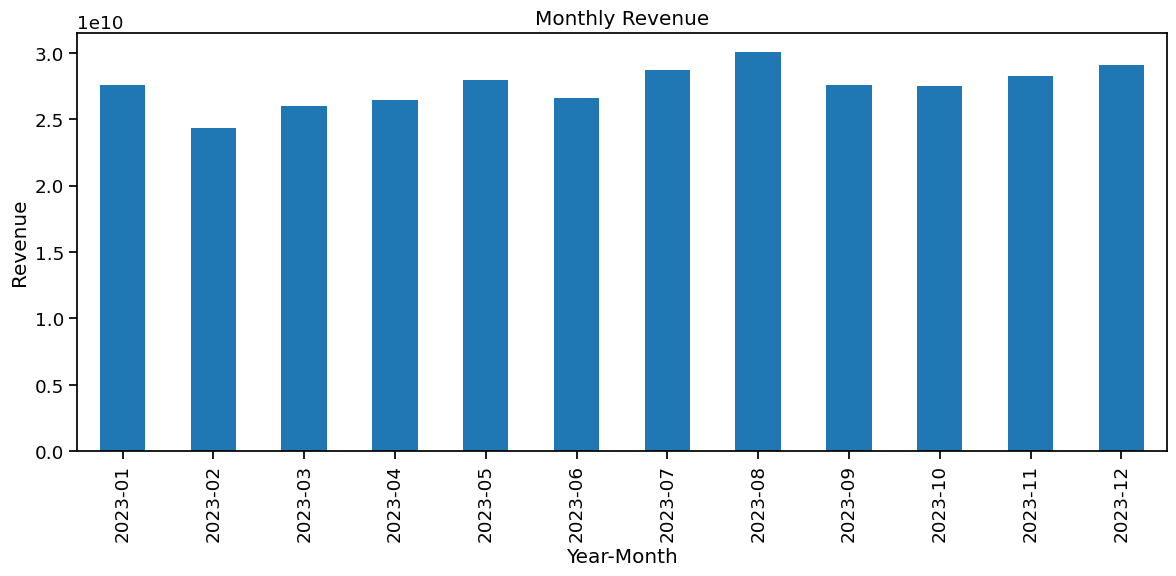

In [87]:
plt.figure(figsize=(12,6))
monthly_revenue.plot(kind='bar')
plt.title('Monthly Revenue')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()


In [88]:
monthly_volume = df.groupby('year_month').size()
monthly_volume


year_month
2023-01    9301
2023-02    8251
2023-03    8845
2023-04    8869
2023-05    9295
2023-06    8854
2023-07    9642
2023-08    9711
2023-09    9253
2023-10    9191
2023-11    9315
2023-12    9660
Freq: M, dtype: int64

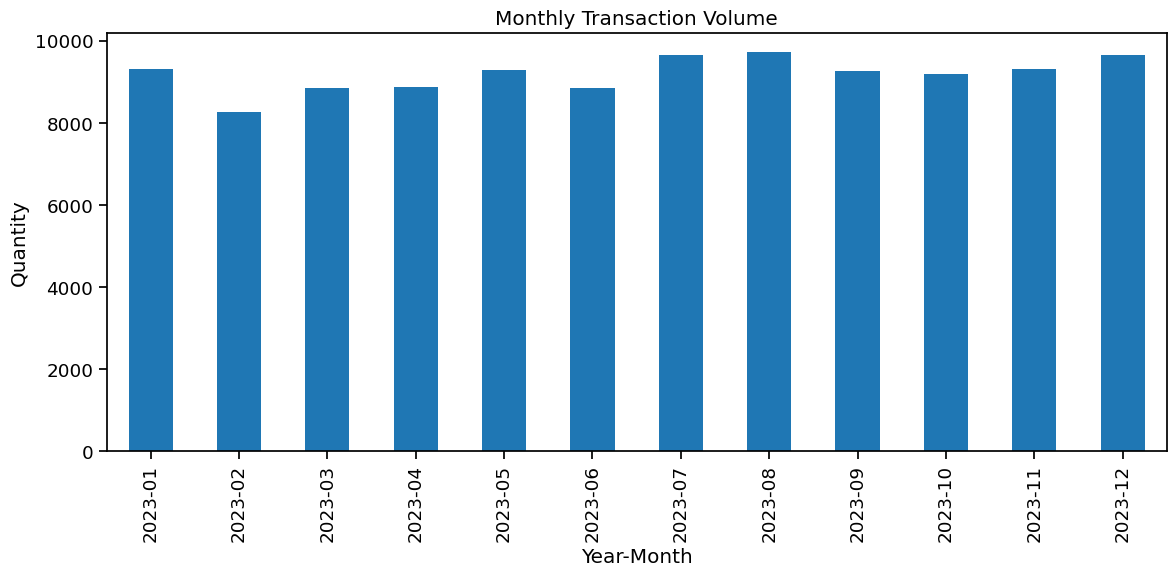

In [89]:
plt.figure(figsize=(12,6))
monthly_volume.plot(kind='bar')
plt.title('Monthly Transaction Volume')
plt.xlabel('Year-Month')
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()

EDA reveals that both monthly transaction volume and monthly revenue exhibit consistent growth, indicating an expanding and increasingly active customer base. However, growth alone does not tell us which customer segments are driving this performance or how their behavior is evolving over time.

# LRFM

Deploying LRFM allows us to:

1. Identify high-value customers sustaining the revenue growth.

2. Detect early-stage customers who show potential for conversion into loyal segments.

3. Spot at-risk or inactive customers despite overall revenue increasing.

first we started by determining the snapshot date, which marks a point in time for data reporting/analysis. In this case, we made it 1 day after last transaction.

In [90]:
snapshot_date = df['TRANSACTION_DATE'].max() + pd.Timedelta(days=30)
snapshot_date

Timestamp('2024-01-30 00:00:00')

## Build LRFM features

We grouped the transactions invoice by customer id to cluster each invoice by its respective customer. To then, we determine their first vs last purchase for the LRFM columns. 

In [91]:
lrfm = df.groupby("CUSTOMER_ID").agg({
    'TRANSACTION_DATE': ['min','max','count'],
    'TOTAL_PRICE': 'sum'
})



In [92]:
lrfm.columns = ['first_purchase','last_purchase','F','M']


In [93]:
lrfm['R'] = (snapshot_date - lrfm['last_purchase']).dt.days
lrfm['L'] = (lrfm['last_purchase'] - lrfm['first_purchase']).dt.days

In [94]:
lrfm_features = lrfm[['L','R','F','M']]



In [95]:
lrfm


,first_purchase,last_purchase,F,M,R,L
CUSTOMER_ID,,,,,,
1,2023-01-01,2023-12-31,2544,97828660,30,364
2,2023-01-02,2023-12-31,1501,61316830,30,363
3,2023-01-01,2023-12-31,2480,94721220,30,364
4,2023-01-01,2023-12-30,1535,62710350,31,363
5,2023-01-01,2023-12-31,2765,104411690,30,364
6,2023-01-01,2023-12-31,2660,104527130,30,364
7,2023-01-02,2023-12-31,2582,100297100,30,363
8,2023-01-01,2023-12-31,2631,103293800,30,364
9,2023-01-02,2023-12-31,2424,86184580,30,363


In [96]:
lrfm = lrfm.drop(columns=['first_purchase','last_purchase'])


In [97]:
lrfm

,F,M,R,L
CUSTOMER_ID,,,,
1,2544,97828660,30,364
2,1501,61316830,30,363
3,2480,94721220,30,364
4,1535,62710350,31,363
5,2765,104411690,30,364
6,2660,104527130,30,364
7,2582,100297100,30,363
8,2631,103293800,30,364
9,2424,86184580,30,363


In [98]:
lrfm = lrfm.reset_index()


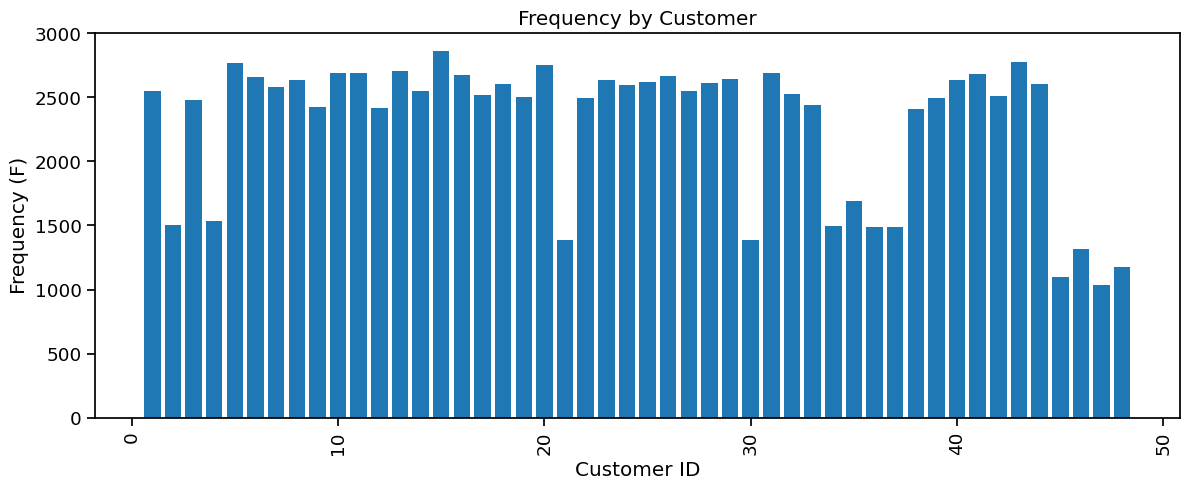

In [99]:
lrfm_sorted = lrfm.sort_values('F', ascending=False)

plt.figure(figsize=(14,5))
plt.bar(lrfm_sorted['CUSTOMER_ID'], lrfm_sorted['F'])
plt.xlabel("Customer ID")
plt.ylabel("Frequency (F)")
plt.title("Frequency by Customer")
plt.xticks(rotation=90)
plt.show()


Based on this distribution, some customers show very high purchasing frequency (2500–2800 orders) while others are much lower (~1000–1500 orders).

Implication:

The customer base is heterogeneous, meaning not all customers contribute equally.

This is exactly why LRFM segmentation is needed—to distinguish:

1. High-value frequent buyers

2. Low-frequency customers

3. Dormant or at-risk customers

# Unsupervised ML

Unsupervised models automatically group customers based on behavior patterns from LRFM:

L = Length (tenure)

R = Recency

F = Frequency

M = Monetary

These models help uncover natural structures in the data

In [100]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(lrfm[['L','R','F','M']])


In [101]:
%matplotlib inline


## DBSCAN

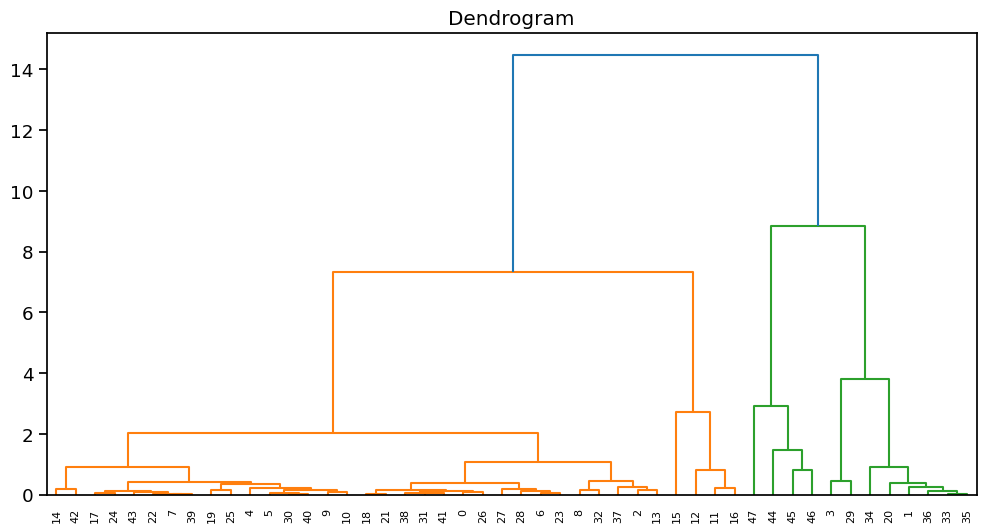

In [ ]:


Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Dendrogram")
plt.show()


In [ ]:



list_eps = [0.2, 0.3, 0.4, 0.5]
list_min_samples = [4, 5, 6, 7]

results = []

for eps in list_eps:
    for min_samples in list_min_samples:

        print(f"--- eps={eps}, min_samples={min_samples} ---")

        # Fit DBSCAN
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)

        unique_labels = np.unique(labels)
        print("Cluster labels:", unique_labels)

        # Count members per cluster (handling -1 noise)
        counts = np.bincount(labels + 1)
        print("Members per cluster:", counts)

        # Compute silhouette score ONLY if DBSCAN created ≥ 2 clusters
        if len(unique_labels[unique_labels != -1]) >= 2:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = -1  # invalid silhouette condition

        print("Silhouette Score:", sil)
        print()

        # Save results
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "silhouette": sil,
            "clusters": unique_labels,
            "members": counts
        })



--- eps=0.2, min_samples=4 ---
Cluster labels: [-1  0  1]
Members per cluster: [15 29  4]
Silhouette Score: 0.5015158671082639

--- eps=0.2, min_samples=5 ---
Cluster labels: [-1  0]
Members per cluster: [19 29]
Silhouette Score: -1

--- eps=0.2, min_samples=6 ---
Cluster labels: [-1  0]
Members per cluster: [20 28]
Silhouette Score: -1

--- eps=0.2, min_samples=7 ---
Cluster labels: [-1  0]
Members per cluster: [22 26]
Silhouette Score: -1

--- eps=0.3, min_samples=4 ---
Cluster labels: [-1  0  1]
Members per cluster: [11 32  5]
Silhouette Score: 0.6299140630247244

--- eps=0.3, min_samples=5 ---
Cluster labels: [-1  0  1]
Members per cluster: [12 31  5]
Silhouette Score: 0.5956584813362586

--- eps=0.3, min_samples=6 ---
Cluster labels: [-1  0]
Members per cluster: [18 30]
Silhouette Score: -1

--- eps=0.3, min_samples=7 ---
Cluster labels: [-1  0]
Members per cluster: [18 30]
Silhouette Score: -1

--- eps=0.4, min_samples=4 ---
Cluster labels: [-1  0  1]
Members per cluster: [11 32 

In [104]:
dbscan_result = pd.DataFrame(results)

dbscan_result = dbscan_result.sort_values(
    by="silhouette",
    ascending=False
).reset_index(drop=True)

dbscan_result



,eps,min_samples,silhouette,clusters,members
0,0.3,4,0.629914,"[-1, 0, 1]","[11, 32, 5]"
1,0.5,5,0.629914,"[-1, 0, 1]","[11, 32, 5]"
2,0.4,5,0.629914,"[-1, 0, 1]","[11, 32, 5]"
3,0.4,4,0.629914,"[-1, 0, 1]","[11, 32, 5]"
4,0.5,4,0.629914,"[-1, 0, 1]","[11, 32, 5]"
5,0.3,5,0.595658,"[-1, 0, 1]","[12, 31, 5]"
6,0.2,4,0.501516,"[-1, 0, 1]","[15, 29, 4]"
7,0.2,5,-1.000000,"[-1, 0]","[19, 29]"
8,0.3,7,-1.000000,"[-1, 0]","[18, 30]"
9,0.3,6,-1.000000,"[-1, 0]","[18, 30]"


In [105]:
# Fit DBScan
dbscan = DBSCAN(eps=0.5, min_samples=4)
clusters_dbs = dbscan.fit_predict(X_scaled)

print('cluster: \n',clusters_dbs)

cluster: 
 [ 0  1  0 -1  0  0  0  0  0  0  0 -1 -1  0  0 -1 -1  0  0  0  1  0  0  0
  0  0  0  0  0 -1  0  0  0  1 -1  1  1  0  0  0  0  0  0  0 -1 -1 -1 -1]


In [106]:
print('Silhouette score DBScan:', silhouette_score(X_scaled, clusters_dbs))

Silhouette score DBScan: 0.6299140630247244


In [107]:
dbscan = DBSCAN(eps=0.5, min_samples=4)
db_labels = dbscan.fit_predict(X_scaled)




In [108]:
lrfm['DBScan'] = db_labels


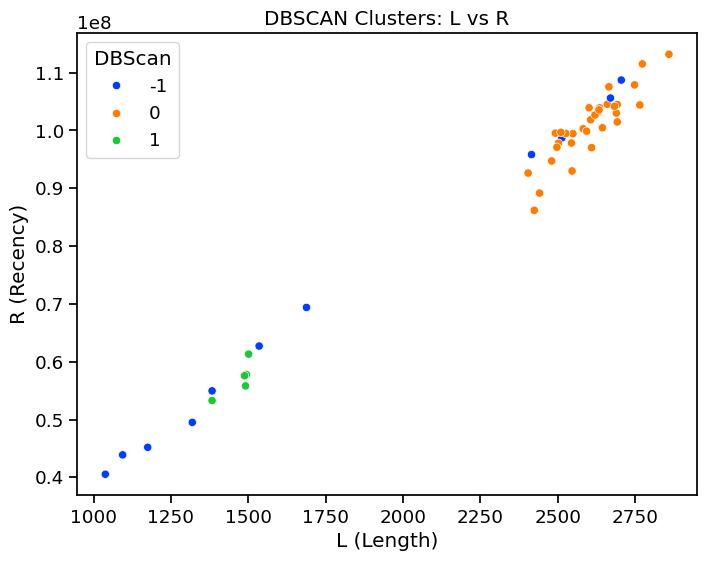

In [109]:


plt.figure(figsize=(8,6))
sns.scatterplot(
    x='F',
    y='M',
    hue='DBScan',
    data=lrfm,
    palette='bright'
)
plt.xlabel('L (Length)')
plt.ylabel('R (Recency)')
plt.title('DBSCAN Clusters: L vs R')
plt.show()


The result shows that with utilizing DBSCAN we can only showcase two groups on the maximum epsilon and min samples. Hence, we would need to deploy other model as comparison

In [110]:
lrfm.columns


Index(['CUSTOMER_ID', 'F', 'M', 'R', 'L', 'DBScan'], dtype='object')

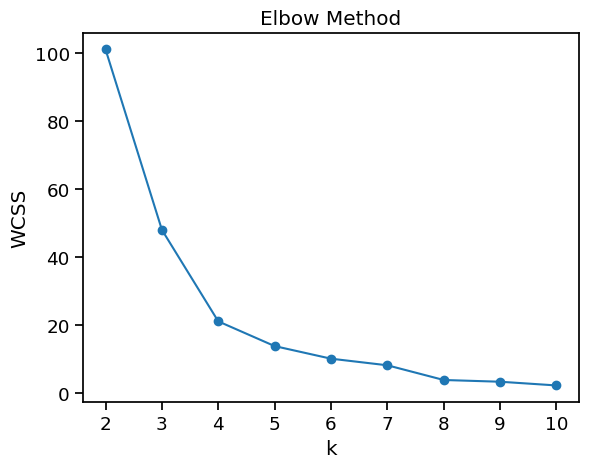

In [111]:

wcss = []
K = range(2,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(K, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.show()

In [112]:


silhouette_scores = {}

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

silhouette_scores


{2: 0.6802555546296357,
 3: 0.6932865804517786,
 4: 0.7573948981167441,
 5: 0.785933088524995,
 6: 0.7761246780971515,
 7: 0.7330604638384294,
 8: 0.5427353455697389,
 9: 0.5030987480720102,
 10: 0.48629288128638565}

In [113]:
lrfm

,CUSTOMER_ID,F,M,R,L,DBScan
0,1,2544,97828660,30,364,0
1,2,1501,61316830,30,363,1
2,3,2480,94721220,30,364,0
3,4,1535,62710350,31,363,-1
4,5,2765,104411690,30,364,0
5,6,2660,104527130,30,364,0
6,7,2582,100297100,30,363,0
7,8,2631,103293800,30,364,0
8,9,2424,86184580,30,363,0
9,10,2689,103009700,30,364,0


In [114]:
kmeans = KMeans(n_clusters=5, random_state=42)
lrfm['cluster'] = kmeans.fit_predict(X_scaled)



In [115]:
sil = silhouette_score(X_scaled, lrfm['cluster'])
sil


0.785933088524995

In [116]:
cluster_profile = lrfm.groupby('cluster')[['L','R','F','M']].mean().round(2)
cluster_profile



,L,R,F,M
cluster,,,,
0,363.81,30.00,2602.97,1.008009e+08
1,219.75,30.75,1156.50,4.478389e+07
2,363.50,30.00,1507.50,5.919313e+07
3,362.75,31.25,2575.75,1.022104e+08
4,363.00,31.00,1459.00,5.883420e+07


In [117]:
lrfm = df.groupby("CUSTOMER_ID").agg({
    'TRANSACTION_DATE': ['min','max','count'],
    'TOTAL_PRICE': 'sum'
})

lrfm.columns = ['first_purchase','last_purchase','F','M']

# Recency & Lifetime
lrfm['R'] = (snapshot_date - lrfm['last_purchase']).dt.days
lrfm['L'] = (lrfm['last_purchase'] - lrfm['first_purchase']).dt.days
 #spending score
lrfm['S'] = lrfm['M'] / lrfm['F']

In [118]:
# Min-max normalization to 0–100
min_S = lrfm['S'].min()
max_S = lrfm['S'].max()

lrfm['S_score'] = ((lrfm['S'] - min_S) / (max_S - min_S)) * 100


In [119]:
lrfm

,first_purchase,last_purchase,F,M,R,L,S,S_score
CUSTOMER_ID,,,,,,,,
1,2023-01-01,2023-12-31,2544,97828660,30,364,38454.661950,52.242598
2,2023-01-02,2023-12-31,1501,61316830,30,363,40850.652898,95.406118
3,2023-01-01,2023-12-31,2480,94721220,30,364,38194.040323,47.547528
4,2023-01-01,2023-12-30,1535,62710350,31,363,40853.648208,95.460078
5,2023-01-01,2023-12-31,2765,104411690,30,364,37761.913201,39.762804
6,2023-01-01,2023-12-31,2660,104527130,30,364,39295.913534,67.397655
7,2023-01-02,2023-12-31,2582,100297100,30,363,38844.732765,59.269682
8,2023-01-01,2023-12-31,2631,103293800,30,364,39260.281262,66.755744
9,2023-01-02,2023-12-31,2424,86184580,30,363,35554.694719,0.000000


In [120]:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(lrfm[['F','M']])





In [121]:
kmeans = KMeans(n_clusters=5, random_state=42)
lrfm['cluster'] = kmeans.fit_predict(X_scaled)



In [122]:
sil = silhouette_score(X_scaled, lrfm['cluster'])
sil


0.5083792897765215

In [123]:
cluster_profile = lrfm.groupby('cluster')[['L','R','F','M','S','S_score']].mean().round(2)
cluster_profile



,L,R,F,M,S,S_score
cluster,,,,,,
0,363.79,30.16,2682.68,1.050639e+08,39163.92,65.02
1,315.67,30.67,1361.67,5.258523e+07,38601.60,54.89
2,363.50,30.17,1532.83,6.076366e+07,39601.85,72.91
3,363.59,30.12,2507.47,9.636801e+07,38429.91,51.80
4,219.33,30.67,1102.33,4.320836e+07,39212.80,65.90


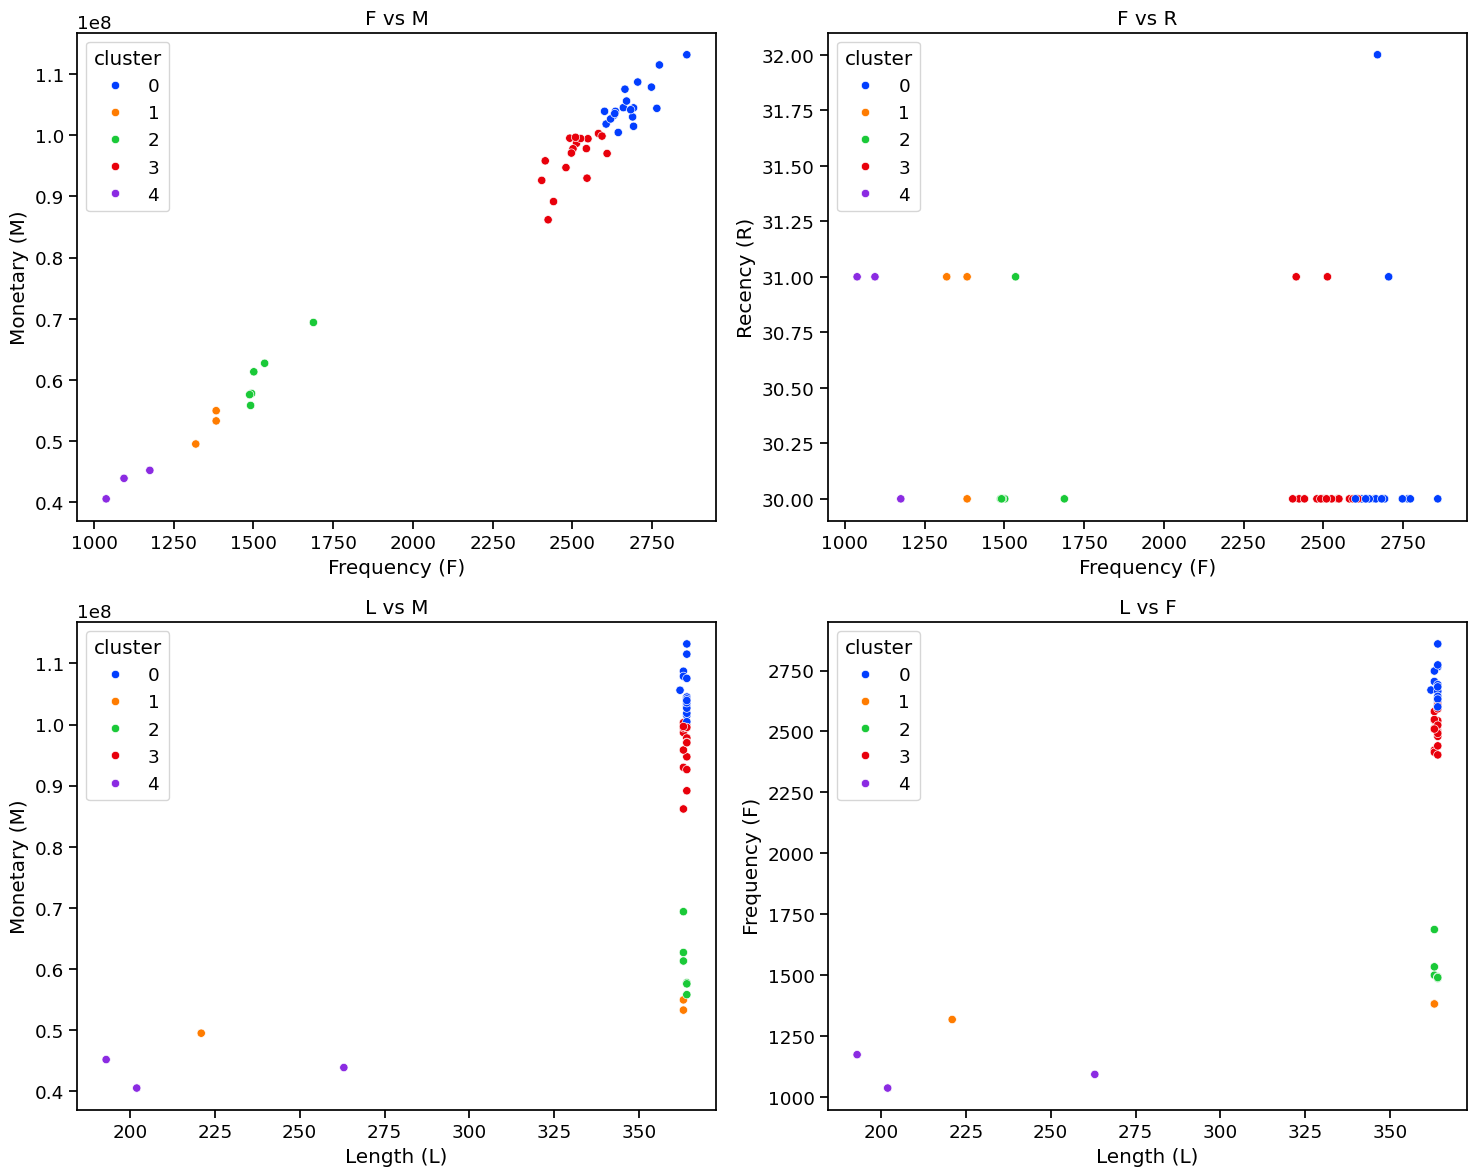

In [124]:
cluster_col = 'cluster'
sns.set_context('notebook', font_scale=1.2)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- F vs M ---
sns.scatterplot(
    x='F', y='M', hue=cluster_col, data=lrfm, palette='bright',
    ax=axes[0, 0]
)
axes[0, 0].set_title("F vs M")
axes[0, 0].set_xlabel("Frequency (F)")
axes[0, 0].set_ylabel("Monetary (M)")

# --- F vs R ---
sns.scatterplot(
    x='F', y='R', hue=cluster_col, data=lrfm, palette='bright',
    ax=axes[0, 1]
)
axes[0, 1].set_title("F vs R")
axes[0, 1].set_xlabel("Frequency (F)")
axes[0, 1].set_ylabel("Recency (R)")

# --- L vs M ---
sns.scatterplot(
    x='L', y='M', hue=cluster_col, data=lrfm, palette='bright',
    ax=axes[1, 0]
)
axes[1, 0].set_title("L vs M")
axes[1, 0].set_xlabel("Length (L)")
axes[1, 0].set_ylabel("Monetary (M)")

# --- L vs F ---
sns.scatterplot(
    x='L', y='F', hue=cluster_col, data=lrfm, palette='bright',
    ax=axes[1, 1]
)
axes[1, 1].set_title("L vs F")
axes[1, 1].set_xlabel("Length (L)")
axes[1, 1].set_ylabel("Frequency (F)")

# tighten spacing
plt.tight_layout()
plt.show()


Based on the clustering results and the pairwise visualizations of LRFM features, Frequency (F) and Monetary (M) emerge as the most meaningful dimensions for customer segmentation. Unlike Recency and Length, which show limited variation and weaker separation, the F vs M analysis displays clear, well-defined clusters that correspond directly to customer value and spending patterns. 

<Axes: xlabel='cluster', ylabel='M'>

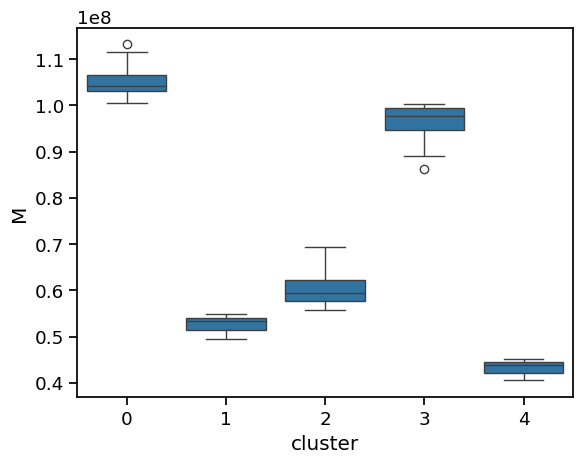

In [140]:
sns.boxplot(data=lrfm, x='cluster', y='M')


<Axes: xlabel='cluster', ylabel='F'>

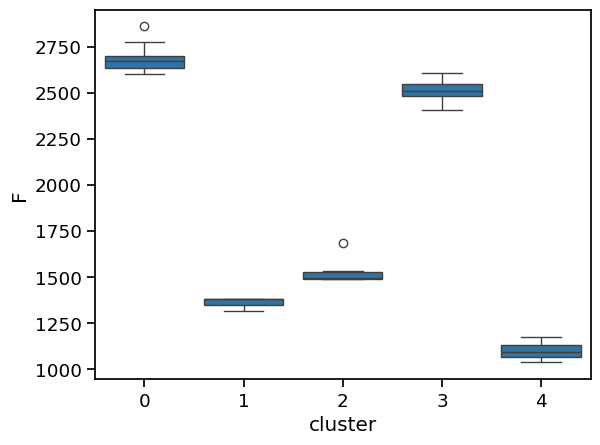

In [141]:
sns.boxplot(data=lrfm, x='cluster', y='F')

Based on the F & M it shows a consistency that cluster 0 has both the highest frequency and monetary contribution and the same rule applies to the other clusters. Hence, we can now label the cluster accordingly.

## Cluster Mapping

The cluster mapping is based on the LRFM mean values of each group, where:
1. Cluster 0 shows the highest purchase frequency and monetary value and is therefore labeled “VIP,”
2. Cluster 3—slightly lower but still very strong in both metrics—is classified as “Loyal High-Value.” 
3. Cluster 2 has a long customer lifecycle with medium spending and frequency, making it “Loyal Mid-Value.” 
4. Cluster 1 sits at moderate levels across frequency, monetary value, and lifecycle, fitting the “Mid-Range” profile. 
5. Cluster 4 has the lowest lifecycle, frequency, and monetary value, indicating weak loyalty and low contribution, so it is labeled “At-Risk.”

In [169]:
cluster_map = {
    0: 'VIP',
    3: 'Loyal High-Value',
    2: 'Loyal Mid-Value',
    1: 'Mid-Range',
    4: 'At-Risk'
}

lrfm['cluster_label'] = lrfm['cluster'].map(cluster_map)


In [170]:
cluster_map

{0: 'VIP',
 3: 'Loyal High-Value',
 2: 'Loyal Mid-Value',
 1: 'Mid-Range',
 4: 'At-Risk'}

In [158]:
lrfm.drop(columns=['S','S_score'], inplace=True)

In [162]:
lrfm

,first_purchase,last_purchase,F,M,R,L,cluster,cluster_label
CUSTOMER_ID,,,,,,,,
1,2023-01-01,2023-12-31,2544,97828660,30,364,3,Loyal
2,2023-01-02,2023-12-31,1501,61316830,30,363,2,Mid-tier
3,2023-01-01,2023-12-31,2480,94721220,30,364,3,Loyal
4,2023-01-01,2023-12-30,1535,62710350,31,363,2,Mid-tier
5,2023-01-01,2023-12-31,2765,104411690,30,364,0,VIP
6,2023-01-01,2023-12-31,2660,104527130,30,364,0,VIP
7,2023-01-02,2023-12-31,2582,100297100,30,363,3,Loyal
8,2023-01-01,2023-12-31,2631,103293800,30,364,0,VIP
9,2023-01-02,2023-12-31,2424,86184580,30,363,3,Loyal


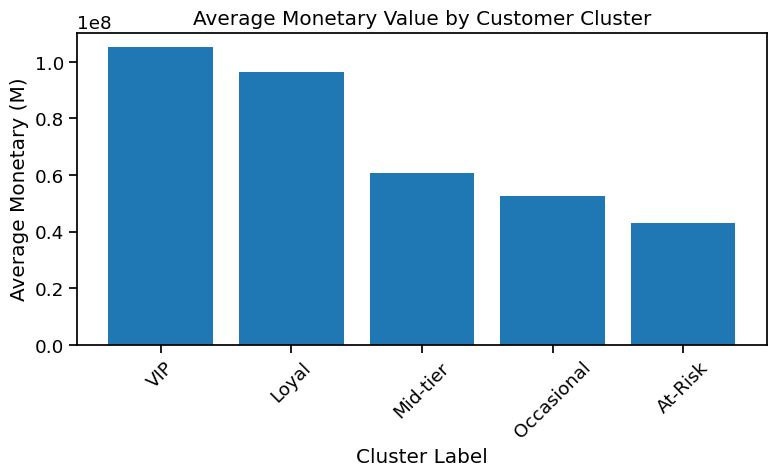

In [ ]:



order = ['VIP', 'Loyal', 'Mid-tier', 'Occasional', 'At-Risk']

# Group and compute mean
m_by_cluster = lrfm.groupby('cluster_label')['M'].mean().reset_index()

# Convert cluster_label to a categorical type with the specified order
m_by_cluster['cluster_label'] = pd.Categorical(
    m_by_cluster['cluster_label'],
    categories=order,
    ordered=True
)

# Sort by that order
m_by_cluster = m_by_cluster.sort_values('cluster_label')

# Plot
plt.figure(figsize=(8,5))
plt.bar(m_by_cluster['cluster_label'], m_by_cluster['M'])
plt.xlabel('Cluster Label')
plt.ylabel('Average Monetary (M)')
plt.title('Average Monetary Value by Customer Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [168]:
cluster_stats = lrfm.groupby('cluster')[['L','R','F','M']].mean()
cluster_stats


,L,R,F,M
cluster,,,,
0,363.789474,30.157895,2682.684211,1.050639e+08
1,315.666667,30.666667,1361.666667,5.258523e+07
2,363.500000,30.166667,1532.833333,6.076366e+07
3,363.588235,30.117647,2507.470588,9.636801e+07
4,219.333333,30.666667,1102.333333,4.320836e+07


In [177]:
cluster_1 = lrfm[lrfm['cluster'] == 1]
cluster_1.head()


,first_purchase,last_purchase,F,M,R,L,cluster,cluster_label
CUSTOMER_ID,,,,,,,,
21,2023-01-02,2023-12-31,1383,53287170,30,363,1,Mid-Range
30,2023-01-01,2023-12-30,1383,54958040,31,363,1,Mid-Range
46,2023-05-23,2023-12-30,1319,49510490,31,221,1,Mid-Range


In [178]:
cluster_4 = lrfm[lrfm['cluster'] == 4]
cluster_4.head()

,first_purchase,last_purchase,F,M,R,L,cluster,cluster_label
CUSTOMER_ID,,,,,,,,
45,2023-04-11,2023-12-30,1094,43891030,31,263,4,At-Risk
47,2023-06-11,2023-12-30,1038,40537650,31,202,4,At-Risk
48,2023-06-21,2023-12-31,1175,45196390,30,193,4,At-Risk


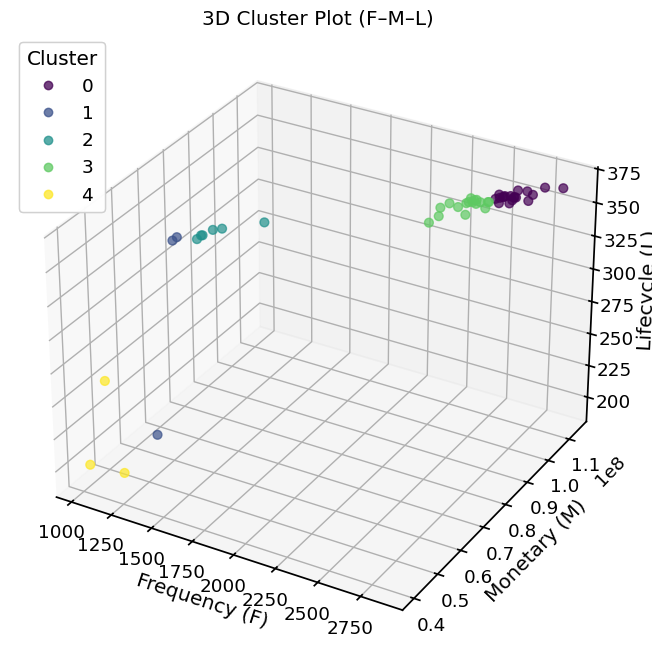

In [ ]:


# Prepare figure
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter
scatter = ax.scatter(
    lrfm['F'],
    lrfm['M'],
    lrfm['L'],
    c=lrfm['cluster'],
    alpha=0.7,
    s=40
)

# Labels
ax.set_xlabel('Frequency (F)')
ax.set_ylabel('Monetary (M)')
ax.set_zlabel('Lifecycle (L)')
ax.set_title('3D Cluster Plot (F–M–L)')

# Add legend
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.show()


VIP & High-Value Loyal (0 & 3): Generate the most revenue, show consistent purchase behavior, and have the longest lifecycle. They should receive exclusive programs and rewards.

Mid-Range & Loyal Mid-Value (1 & 2): Stable customers with strong potential to upgrade. Target with cross-selling or loyalty promotions.

At-Risk (4): Lowest revenue and shortest lifecycle. Needs retention strategies, reactivation campaigns, or targeted marketing.

The LRFM framework provides a structured way to evaluate customers based on their transaction behavior, allowing businesses to build clear segmentation criteria depending on strategic needs—whether focusing on loyalty (Recency and Frequency), value (Monetary), or customer lifecycle (Length). In this study, we applied unsupervised machine learning to identify natural groupings within the customer base and ultimately selected segmentation using Frequency vs. Monetary. This approach allowed us to differentiate high-value, high-activity customers from low-spend or low-engagement groups without relying on predefined labels. Through clustering, we uncovered distinct behavioral patterns that support targeted marketing, retention strategies, and resource allocation, making LRFM a powerful foundation for data-driven customer segmentation

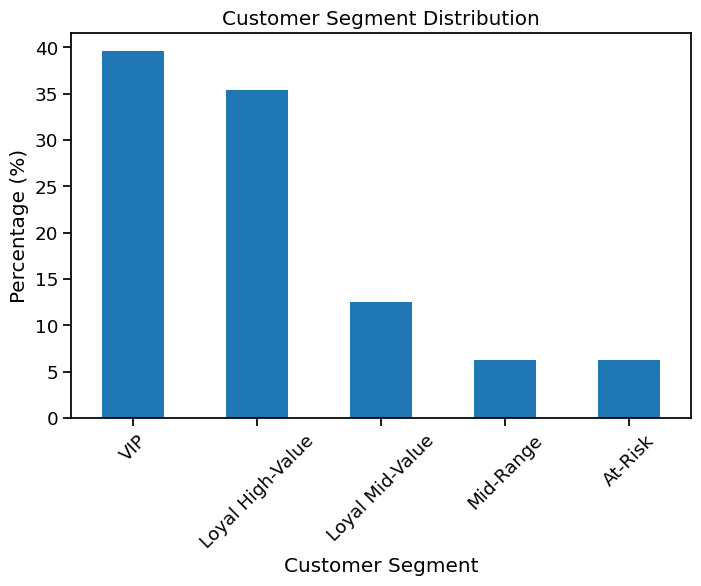

In [173]:
import matplotlib.pyplot as plt

segment_pct.plot(kind='bar', figsize=(8,5))
plt.title("Customer Segment Distribution")
plt.ylabel("Percentage (%)")
plt.xlabel("Customer Segment")
plt.xticks(rotation=45)
plt.show()


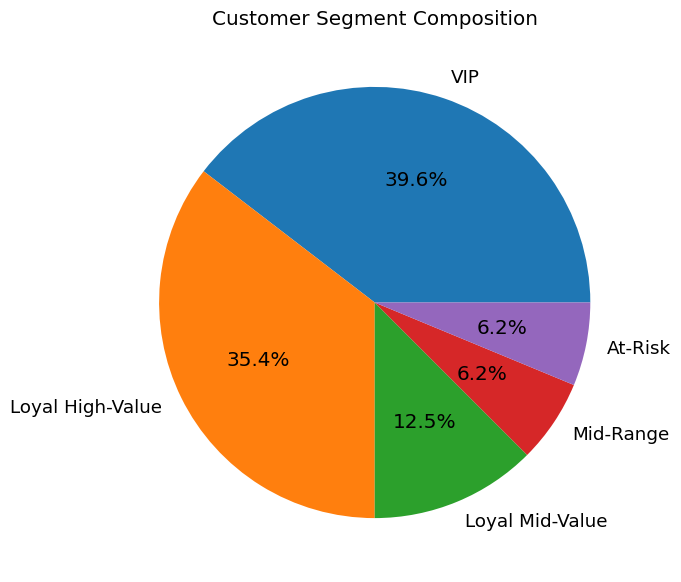

In [179]:
lrfm['cluster_label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7),
    ylabel=""
)
plt.title("Customer Segment Composition")
plt.show()


In [181]:
summary_table = lrfm.groupby('cluster_label')[['L', 'R', 'F', 'M']].mean().round(2)
summary_table = summary_table.sort_values(by='M', ascending=False)
summary_table


,L,R,F,M
cluster_label,,,,
VIP,363.79,30.16,2682.68,1.050639e+08
Loyal High-Value,363.59,30.12,2507.47,9.636801e+07
Loyal Mid-Value,363.50,30.17,1532.83,6.076366e+07
Mid-Range,315.67,30.67,1361.67,5.258523e+07
At-Risk,219.33,30.67,1102.33,4.320836e+07


# Conclusion and Business Reccomendation

**Customer Segmentation**

Based on our unsupervised machine learning, we obtain 5 customer segmentation: 

1. VIP (Cluster 0) – Highest Frequency & Monetary Value

Characteristics:

Extremely high transaction frequency

Highest spending (105M average)

Long lifecycle (high loyalty)

Recommended Actions:

Maintain loyalty with exclusive perks (early access, premium service)

Introduce VIP-only product bundles to reinforce status

Personalize communication and offer premium customer support

Protect this segment above all — they contribute disproportionally to revenue

2. Loyal High-Value (Cluster 3) – Almost VIP

Characteristics:

Very high F and M, slightly below VIP

Long-term, stable customers

Recommended Actions:

Run upgrade campaigns to turn them into full VIP

Offer personalized rewards, such as milestone bonuses

Encourage subscription or recurring purchasing programs

Invite them to loyalty events or early product previews

3. Loyal Mid-Value (Cluster 2) – High Lifecycle, Medium Value

Characteristics:

Loyal customers with long relationships

Medium spending and frequency

Recommended Actions:

Perfect segment for cross-selling and upselling

Promote higher-tier products through targeted recommendations

Offer bundled promotions (e.g., “Buy More Save More”)

Strengthen engagement with membership or rewards tracking

4. Mid-Range (Cluster 1) – Moderate Value, Moderate Loyalty

Characteristics:

Reasonable frequency (1300–1500)

Mid-level monetary value

Lifecycle not as strong as loyal clusters

Recommended Actions:

Encourage higher basket size via discount thresholds (e.g., “Spend 50M, get 10% off”)

Improve stickiness through loyalty point multipliers

Re-engage with seasonal campaigns or personalized product recommendations

Convert them toward Loyal Mid-Value status

5. At-Risk / Low-Value (Cluster 4) – Lowest Revenue & Loyalty

Characteristics:

Lowest frequency (≈1100)

Lowest monetary value (≈40M)

Shortest lifecycle (≈200)

Recommended Actions:

Launch reactivation campaigns (limited-time discounts, “We miss you!” emails)

Offer entry-level bundles to bring them back into the purchase cycle

Use retargeting ads with personalized product preferences

If retention is costly, deprioritize and focus budget on higher-value clusters

**Overall Strategic Recommendations**

1. Invest heavily in VIP and High-Value Loyal clusters: These two segments drive the majority of your profit.

2. Raise the value of Mid-Range and Loyal Mid-Value segments through upselling, bundles, and loyalty programs.

3. Apply cost-efficient reactivation strategies for the At-Risk segment—only if ROI is positive.

4. Consider designing a structured loyalty ladder:

5. At-Risk → Mid-Range → Loyal Mid-Value → Loyal High-Value → VIP

6. Use personalized communication driven by LRFM data to increase relevance and reduce churn.

In [ ]:


# Save model
joblib.dump(kmeans, "kmeans_model.pkl")



['kmeans_model.pkl']